Phân tích đơn biến

Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Đọc dữ liệu 


In [2]:
data = pd.read_csv('data/train.csv')

Kiểm tra vài dòng đầu tiên của dữ liệu để xác nhận


In [3]:
print(data.head())


   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False


Kiểm tra có các giá trị NaN (Khuyết) trong tập dữ liệu hay không?
Kết quả cho thấy không có giá trị NaN

In [4]:
missing_data = data.isnull().sum()
print(f"Missing Data:\n{missing_data}\n")

Missing Data:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64



Kiểm tra thống kê mô tả cho các biến số (như Weekly_Sales)

In [5]:
desc_stats = data.describe()
print(f"Descriptive Statistics:\n{desc_stats}\n")

Descriptive Statistics:
               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000



Vẽ biểu đồ phân phối (histogram) cho Weekly_Sales

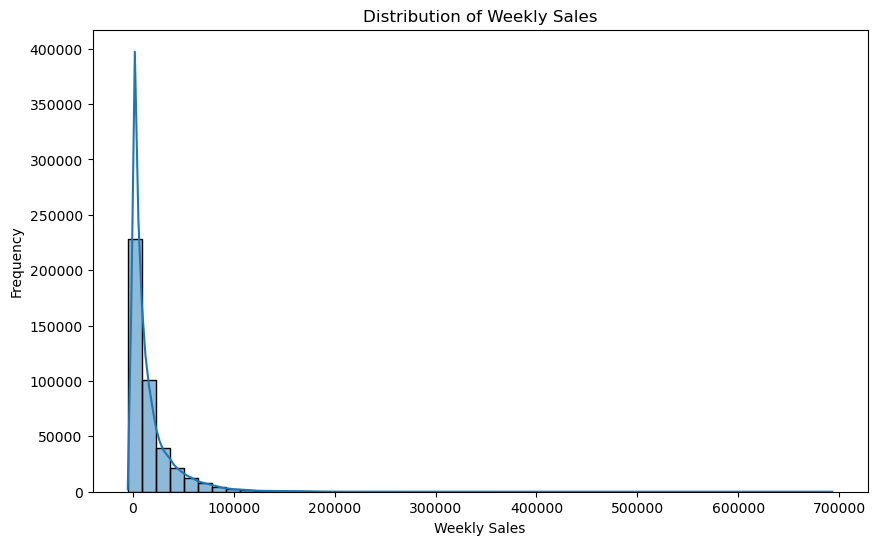

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(data['Weekly_Sales'], kde=True, bins=50)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()

Biểu đồ phân phối Weekly_Sales cho thấy:
- Phân phối lệch phải: Phần lớn doanh thu hàng tuần tập trung ở mức thấp (gần 0), nhưng có một số ít tuần có doanh thu rất cao.
- Ngoại lai: Các giá trị cực cao (trên 100,000) có thể là các ngoại lai, có thể do các sự kiện đặc biệt (khuyến mãi, lễ hội, ...).
- Xử lý: Có thể cần loại bỏ hoặc điều chỉnh ngoại lai và xem xét biến đổi log để làm giảm độ lệch của dữ liệu.
Biểu đồ phản ánh sự phân bố doanh thu không đồng đều, với nhiều tuần có doanh thu thấp và vài tuần có doanh thu rất cao.

Kiểm tra các giá trị ngoại lai (outliers) bằng boxplot

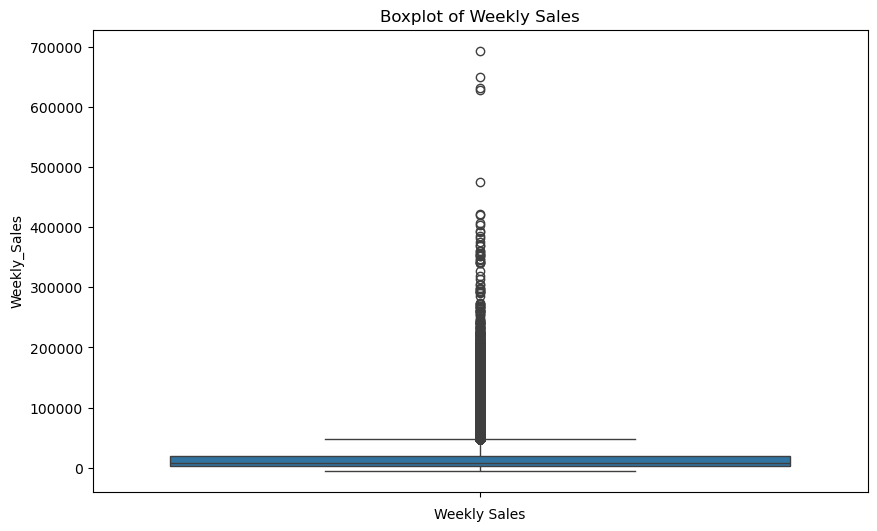

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data['Weekly_Sales'])
plt.title('Boxplot of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.show()

Biểu đồ boxplot của Weekly_Sales cho thấy:
- Ngoại lai: Có nhiều giá trị ngoại lai (outliers) với doanh thu rất cao (trên 200,000), có thể do các sự kiện đặc biệt như khuyến mãi hoặc lễ hội.
- Phân phối lệch phải: Dữ liệu có phần lớn nằm ở phía thấp (doanh thu thấp), với một vài tuần có doanh thu cực kỳ cao.
- Giới hạn phân phối: Phần lớn doanh thu nằm trong khoảng từ 0 đến 100,000.

Kiểm tra và xử lý giá trị ngoại lai bằng phương pháp IQR (Interquartile Range)
Tính IQR và xác định ngưỡng loại bỏ ngoại lai

In [15]:
Q1 = data['Weekly_Sales'].quantile(0.25)
Q3 = data['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR # Ngưỡng dưới
upper_bound = Q3 + 1.5 * IQR # Ngưỡng trên

In [ ]:
#Lọc dữ liệu để loại bỏ các giá trị ngoài ngưỡng
data_filtered = data[(data['Weekly_Sales'] >= lower_bound) & (data['Weekly_Sales'] <= upper_bound)]


Vẽ lại biểu đồ phân phối sau khi loại bỏ các giá trị ngoại lai

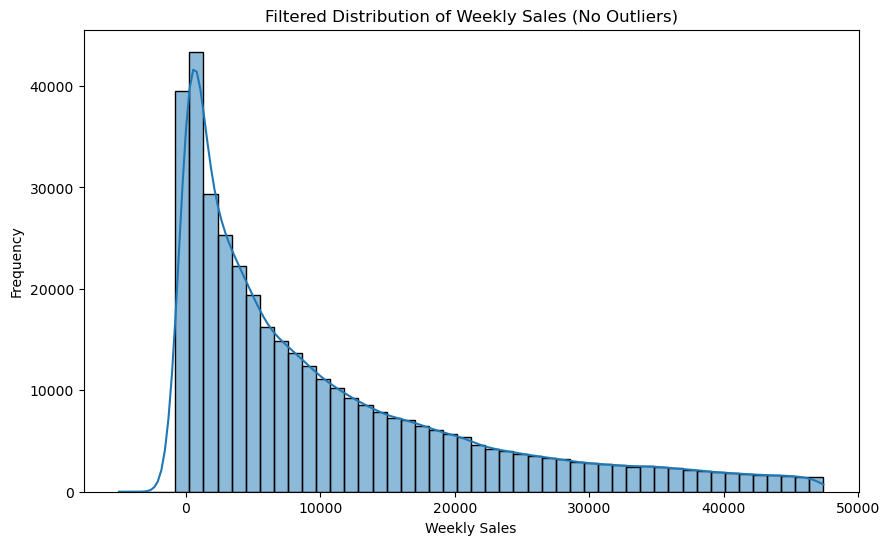

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(data_filtered['Weekly_Sales'], kde=True, bins=50)
plt.title('Filtered Distribution of Weekly Sales (No Outliers)')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()

Tìm dữ liệu bị thiếu trong Data

In [11]:
print(f"Missing values in categorical columns (Store, Dept, etc.):")
print(data[['Store', 'Dept']].isnull().sum())

Missing values in categorical columns (Store, Dept, etc.):
Store    0
Dept     0
dtype: int64


Kiểm tra tần suất các cửa hàng (Store Frequency)

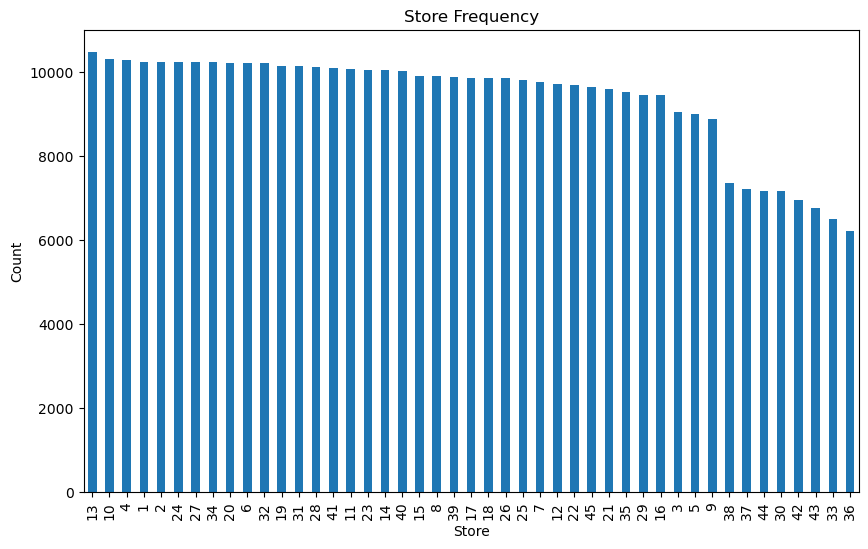

In [12]:
plt.figure(figsize=(10,6))
data['Store'].value_counts().plot(kind='bar')
plt.title('Store Frequency')
plt.xlabel('Store')
plt.ylabel('Count')
plt.show()

Tìm ma trận tương quan

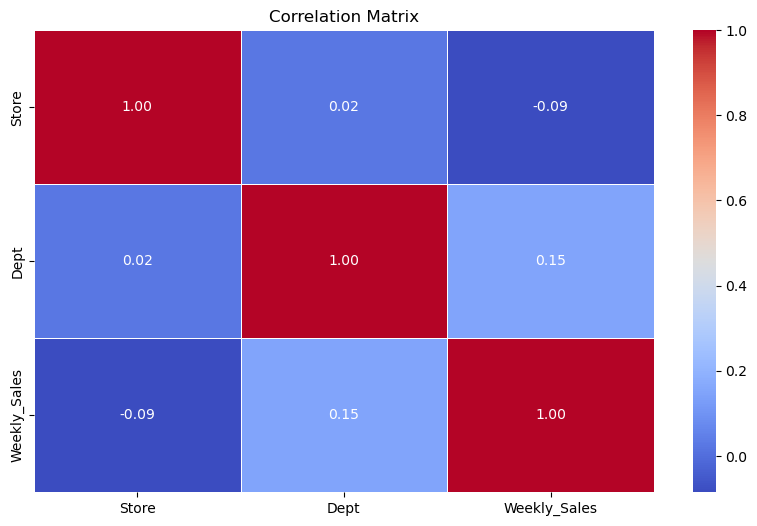

In [13]:
numeric_data = data.select_dtypes(include=[np.number])

# Tính toán ma trận tương quan
correlation_matrix = numeric_data.corr()

# Vẽ heatmap để hiển thị ma trận tương quan
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Biểu đồ ma trận tương quan cho thấy:
- Store vs Weekly_Sales: Tương quan yếu (-0.09), cho thấy không có mối quan hệ rõ ràng giữa cửa hàng và doanh thu hàng tuần.
- Dept vs Weekly_Sales: Tương quan yếu (0.15), cho thấy một mối liên hệ nhẹ giữa bộ phận và doanh thu hàng tuần.
- Store vs Dept: Tương quan rất nhỏ (0.02), cho thấy không có mối liên hệ rõ ràng giữa các cửa hàng và bộ phận.

Tóm lại, không có mối quan hệ tuyến tính mạnh giữa Store, Dept, và Weekly_Sales, có thể cần thêm yếu tố khác hoặc mô hình phi tuyến để khám phá sâu hơn.